In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
from article_code.util_files.statistics import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE


# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)
list_cities = sorted(spells.keys())

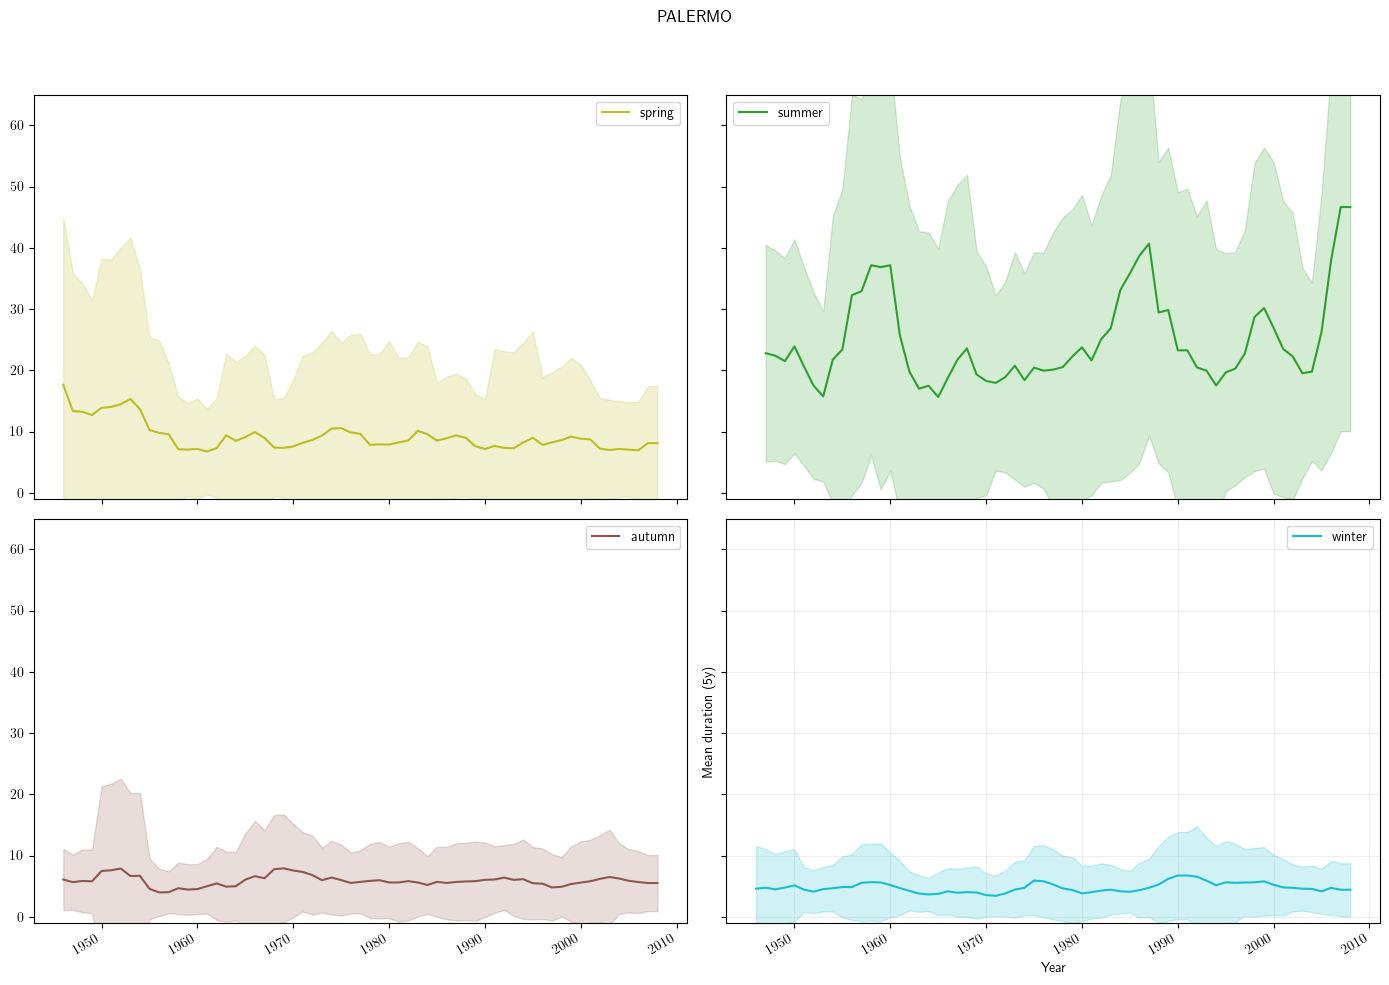

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

NAME_STATION_EXAMPLE = config.STATION_EXAMPLE
mpl.rcParams["text.usetex"] = True
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()
colors = {"spring": "tab:olive","summer": "tab:green","autumn": "tab:brown","winter": "tab:cyan",}

all_handles, all_labels = None, None
all_durations = spells[NAME_STATION_EXAMPLE]["dry_spell"]["duration_spell"]
all_dates = spells[NAME_STATION_EXAMPLE]["dry_spell"]["start_date_spell"]
for ax,season in zip(axes, config.SEASONS):
    season_durations = [dur for dur, date in zip(all_durations, all_dates)
                        if from_date_to_season(date) == season]
    season_dates = [date for dur, date in zip(all_durations, all_dates)
                    if from_date_to_season(date) == season]
    season_dates = pd.to_datetime(pd.Series(season_dates).astype(str), format="%Y%m%d")
    df = pd.DataFrame({"date": season_dates, "duration": season_durations})
    df["year"] = df["date"].dt.year
    g = df.groupby("year")["duration"]
    annual = pd.DataFrame({"count": g.size(),"sum": g.sum(),
        "sumsq": g.apply(lambda s: (s**2).sum())})
    years = np.arange(df["year"].min(), df["year"].max() + 1)
    annual = annual.reindex(years)
    r_count = annual["count"].rolling(window=5, center=True, min_periods=1).sum()
    r_sum   = annual["sum"].rolling(window=5, center=True, min_periods=1).sum()
    r_sumsq = annual["sumsq"].rolling(window=5, center=True, min_periods=1).sum()
    mean5 = r_sum / r_count
    var5 = (r_sumsq - (r_sum**2) / r_count) / (r_count - 1)
    std5 = np.sqrt(var5)
    x = pd.to_datetime(pd.Series(years).astype(str) + "0101", format="%Y%m%d")
    line, = ax.plot(x, mean5.values, label=season, color=colors[season])
    ax.fill_between(x,(mean5 - std5).values,(mean5 + std5).values,
        alpha=0.2,color=colors[season])
    ax.legend()
fig.suptitle(NAME_STATION_EXAMPLE)
ax.set_xlabel("Year")
ax.set_ylabel("Mean duration (5y)")
ax.set_ylim(-1, 65)
ax.grid(alpha=0.2)
if all_handles is None:
    all_handles, all_labels = ax.get_legend_handles_labels()
# fig.legend(all_handles, all_labels, loc="upper center", ncol=4, frameon=False)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
